In [ ]:
import marimo as mo

# Causality-Aware Graph Neural Networks

*August 4 2026*
*Training Workshop: Causality-Aware Temporal Networks*
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*

## Motivation

In previous tutorials, we have introduced time-respecting paths in temporal graphs, and how we can use them to generate higher-order De Bruijn graph models that capture patterns in the causal topology of temporal graphs. In the previous notebook, we have further seen that state-of-the-art temporal GNNs are blind to these patterns, which limits their real-world use.

In this last notebook, we will show how we can use De Bruijn Graph Neural Networks, a causality-aware deep learning architecture for temporal graph data. The details of this approach are introduced [in this paper](https://proceedings.mlr.press/v198/qarkaxhija22a.html). The architecture is implemented in pathpyG and can be readily applied to temporal network data. Below we illustrate this method in a supervised node classification task, i.e. given a temporal graph we will use the temporal-topological patterns in the graph to classify nodes.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import balanced_accuracy_score
from torch_geometric.transforms import RandomNodeSplit

import pathpyG as pp
from pathpyG.nn.dbgnn import DBGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Let us load our small synthetic toy example for a temporal graph with 60.000 time-stamped interactions between 30 nodes. We use the `TemporalGraph` class to load this example from a file containing edges with discrete time-stamps.

In [ ]:
df = pd.read_csv(pp.io.example_data('temporal_clusters.tedges'))
t = pp.io.df_to_temporal_graph(df)

This example has created in such a way that the nodes naturally form three clusters, which are highlighted in the interactive visualization below:

In [ ]:
style = {}
style['node_color'] = ['green']*10+['red']*10+['blue']*10
pp.plot(t, **style, edge_size=4, edge_color='gray');

<marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003e\u003cspan class=\"text-error\"\u003e\u003cstrong\u003eYour output is too large\u003c/strong\u003e\u003c/span\u003e\u003c/span\u003e\n\u003cspan class=\"paragraph\"\u003eYour output is too large for marimo to show. It has a size\nof 16252844 bytes. Did you output this object by accident?\u003c/span\u003e\n\u003cspan class=\"paragraph\"\u003eIf this limitation is a problem for you, you can configure\nthe max output size by adding (eg)\u003c/span\u003e\n\u003cdiv class=\"language-ini codehilite\"\u003e\u003cpre\u003e\u003cspan\u003e\u003c/span\u003e\u003ccode\u003e\u003cspan class=\"k\"\u003e[tool.marimo.runtime]\u003c/span\u003e\n\u003cspan class=\"na\"\u003eoutput_max_bytes\u003c/span\u003e\u003cspan class=\"w\"\u003e \u003c/span\u003e\u003cspan class=\"o\"\u003e=\u003c/span\u003e\u003cspan class=\"w\"\u003e \u003c/span\u003e\u003cspan class=\"s\"\u003e10_000_000\u003c/span\u003e\n\u003c/code\u003e\u003c/pre\u003e\u003c/div\u003e\n\u003cspan class=\"paragraph\"\u003eto your pyproject.toml, or with the environment variable\n\u003ccode\u003eMARIMO_OUTPUT_MAX_BYTES\u003c/code\u003e:\u003c/span\u003e\n\u003cdiv class=\"language-gdscript codehilite\"\u003e\u003cpre\u003e\u003cspan\u003e\u003c/span\u003e\u003ccode\u003e\u003cspan class=\"k\"\u003eexport\u003c/span\u003e\u003cspan class=\"w\"\u003e \u003c/span\u003e\u003cspan class=\"n\"\u003eMARIMO_OUTPUT_MAX_BYTES\u003c/span\u003e\u003cspan class=\"o\"\u003e=\u003c/span\u003e\u003cspan class=\"mi\"\u003e10\u003c/span\u003e\u003cspan class=\"n\"\u003e_000_000\u003c/span\u003e\n\u003c/code\u003e\u003c/pre\u003e\u003c/div\u003e\n\u003cspan class=\"paragraph\"\u003eIncreasing the max output size may cause performance issues.\nIf you run into problems, please reach out\nto us on \u003ca href=\"https://marimo.io/discord?ref=app\" rel=\"noopener noreferrer\" target=\"_blank\"\u003eDiscord\u003c/a\u003e or\n\u003ca href=\"https://github.com/marimo-team/marimo/issues\" rel=\"noopener noreferrer\" target=\"_blank\"\u003eGitHub\u003c/a\u003e.\u003c/span\u003e\u003c/span\u003e"' data-kind='"warn"'>

## Modelling Causal Structures with Higher-Order De Bruijn Graphs

But what is the origin for the cluster pattern? In the visualization above, you will notice that the time-stamped edges randomly interconnect nodes within and across clusters, actually there is no correlation whatsoever between the topology of links and the cluster membership of the nodes. Hence, the notion of clusters does not correspond to the common idea of cluster patterns in static graphs, which we can highlight further by plotting the static time-aggregated network:

In [ ]:
pp.plot(t.to_static_graph(), **style, edge_size=1, edge_color='gray');

<iframe srcdoc='<style>
.label-text {
 fill: #969595;
 font-size: 16px;
 font-family: sans-serif;
}
</style>

<div id = "x36da8f157fb84788acd592e5f4c6dd55"> </div>
<script charset="utf-8">
function render_plot_197a4372a02f4242ad5febb42586709a() {
 const d3 = window.d3;
 if (!d3) { console.error('D3 not loaded'); return; }
const data = {"nodes": [{"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "0"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "1"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "2"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "3"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "4"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "5"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "6"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "7"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "8"}, {"color": "#008000", "size": 15, "opacity": 0.75, "image": null, "uid": "9"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "10"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "11"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "12"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "13"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "14"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "15"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "16"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "17"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "18"}, {"color": "#ff0000", "size": 15, "opacity": 0.75, "image": null, "uid": "19"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "20"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "21"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "22"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "23"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "24"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "25"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "26"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "27"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "28"}, {"color": "#0000ff", "size": 15, "opacity": 0.75, "image": null, "uid": "29"}], "edges": [{"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-3", "source": "0", "target": "3"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-26", "source": "0", "target": "26"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-19", "source": "0", "target": "19"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-24", "source": "0", "target": "24"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-29", "source": "0", "target": "29"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-6", "source": "0", "target": "6"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-22", "source": "0", "target": "22"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-21", "source": "0", "target": "21"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-16", "source": "0", "target": "16"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-17", "source": "0", "target": "17"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-4", "source": "0", "target": "4"}, {"color": "#808080", "size": 1, "opacity": 0.5, "image": null, "uid": "0-23",

In fact, the topology of this graph corresponds to that of a random graph, i.e. there are not patterns whatsoever in the topology of links. Nevertheless, the temporal graph contains a cluster pattern in the topology of causal or time-respecting paths. In particular, the temporal ordering of time-stamped edges is such that nodes with the same cluster label are more frequently connected by time-respecting paths than nodes with different cluster labels. Hence, nodes within the same clusters can more strongly influence each other in a causal way, i.e. via multiple interactions that follow the arrow of time.

Traditional (temporal) graph neural networks will not be able to learn from this pattern, as it is due to the specific microscopic temporal ordering of edges. Using higher-order De Bruijn graph models implemented in pathpyG, we can learn from temporal graph data that contains such patterns. Let us explain this step by step.

Referring to the previous tutorial on causal paths in temporal graphs, we first create a node-time directed acyclic graph that captures the causal structure of the temporal graph. In this small example, we will only consider two time-stamped edges $(u,v;t)$ and $(v,w;t')$ to contribute to a causal path iff $0 < t'-t \leq 1$, i.e. we use a delta for the maximum time difference of one time step.

In [ ]:
m = pp.MultiOrderModel.from_temporal_graph(t, max_order=2)
print(m)

100%|██████████| 60000/60000 [00:18<00:00, 3247.40it/s]


MultiOrderModel with max. order 2


We can get the first and second order networks from the Multi Order Network object. The first order network is the network of nodes and edges, while the second-order network uses first-order edges as nodes and edges represent time-respecting paths of length two. The second order network is a De Bruijn graph that captures temporal-topological patterns in the network.

In [ ]:
g = m.layers[1]
g2 = m.layers[2]

In [ ]:
pp.plot(g, edge_size=2);

<iframe srcdoc='<style>
.label-text {
 fill: #969595;
 font-size: 16px;
 font-family: sans-serif;
}
</style>

<div id = "x9fd5e4f4b7774756944465f505ab2dfd"> </div>
<script charset="utf-8">
function render_plot_99c70c754e9e4dae9decfd3509f8e931() {
 const d3 = window.d3;
 if (!d3) { console.error('D3 not loaded'); return; }
const data = {"nodes": [{"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "0"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "1"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "2"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "3"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "4"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "5"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "6"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "7"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "8"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "9"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "10"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "11"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "12"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "13"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "14"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "15"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "16"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "17"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "18"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "19"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "20"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "21"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "22"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "23"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "24"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "25"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "26"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "27"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "28"}, {"color": "#244a5c", "size": 15, "opacity": 0.75, "image": null, "uid": "29"}], "edges": [{"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-4", "source": "0", "target": "4"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-3", "source": "0", "target": "3"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-29", "source": "0", "target": "29"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-26", "source": "0", "target": "26"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-24", "source": "0", "target": "24"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-23", "source": "0", "target": "23"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-22", "source": "0", "target": "22"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-21", "source": "0", "target": "21"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-19", "source": "0", "target": "19"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-18", "source": "0", "target": "18"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-16", "source": "0", "target": "16"}, {"color": "#4c707b", "size": 2, "opacity": 0.5, "image": null, "uid": "0-15

Since it does not consider patterns in the causal topology of the temporal graph, this is not a meaningful model. We can instead use a second-order De Bruijn graph model, which we can easily fit to the paths:

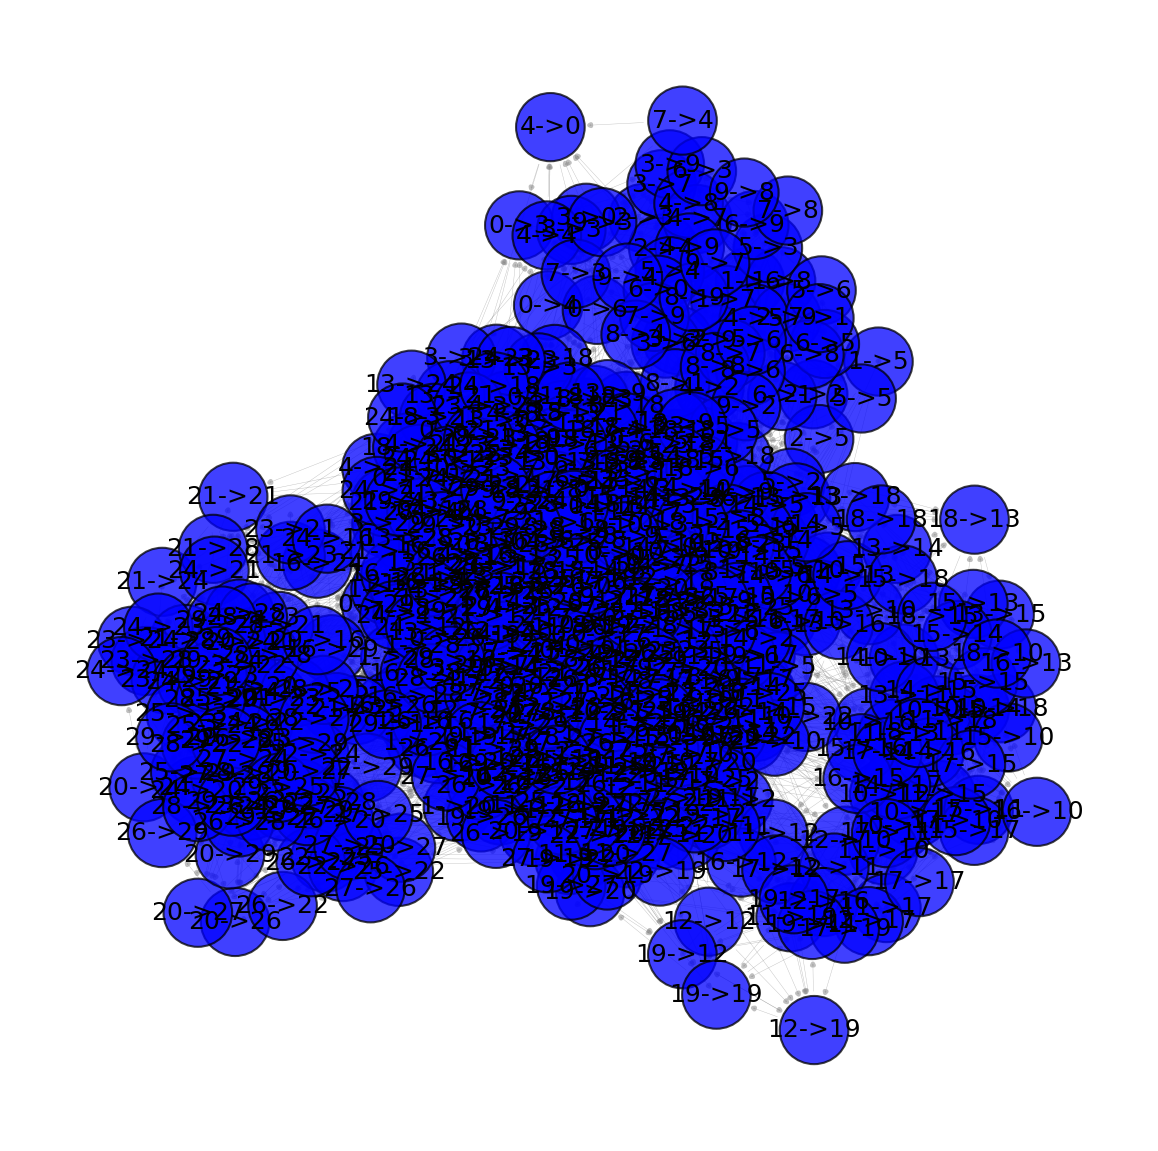

<pathpyG.visualisations._matplotlib.backend.MatplotlibBackend object at 0x74c58a430050>

In [ ]:
_layout = pp.layout(g2, layout='Fruchterman-Reingold', seed=1, iterations=300)
pp.plot(g2, edge_size=0.1, edge_color='gray', node_color='blue', backend='matplotlib', layout=_layout)

In this graph, every node is a link and links correspond to causal paths of length two, i.e. temporally ordered sequences consisting of two edges that overlap in the center node. In this graph, we clearly see a cluster pattern that is due to the way in which temporal edges are ordered in time. In particular, we see three clusters, where the edges in three of the clusters correspond to causal paths of length two that connect nodes within each of the three clusters. The edges in the fourth cluster (in the center of the visualization) represent causal paths that connect nodes in different clusters.

## Comparison to Temporal Graph with Shuffled Time Stamps

You may wonder whether this pattern is really due to the temporal ordering of time-stamped edges. It is easy to check this. We can simply randomly shuffle the time stamps of all edges, which will break any correlations in the temporal ordering that lead to patterns in the causal topology.

We repeat the path calculation for this shuffled temporal graph and construct the second-order De Bruijn Graph model again:

In [ ]:
t_shuffled = pp.io.df_to_temporal_graph(df)
t_shuffled.shuffle_time()

In [ ]:
g2_shuffled = pp.MultiOrderModel.from_temporal_graph(t_shuffled, max_order=2).layers[2]
print(g2_shuffled)

100%|██████████| 60000/60000 [00:18<00:00, 3256.70it/s]


Higher-order graph of order 2 with 557 nodes and 2032 edges
(over 30 first-order nodes)
{   'Edge Attributes': {'edge_weight': "<class 'torch.Tensor'> -> torch.Size([2032])"},
    'Graph Attributes': {'inverse_idx': "<class 'torch.Tensor'> -> torch.Size([60000])", 'num_nodes': "<class 'int'>"},
    'Node Attributes': {}}


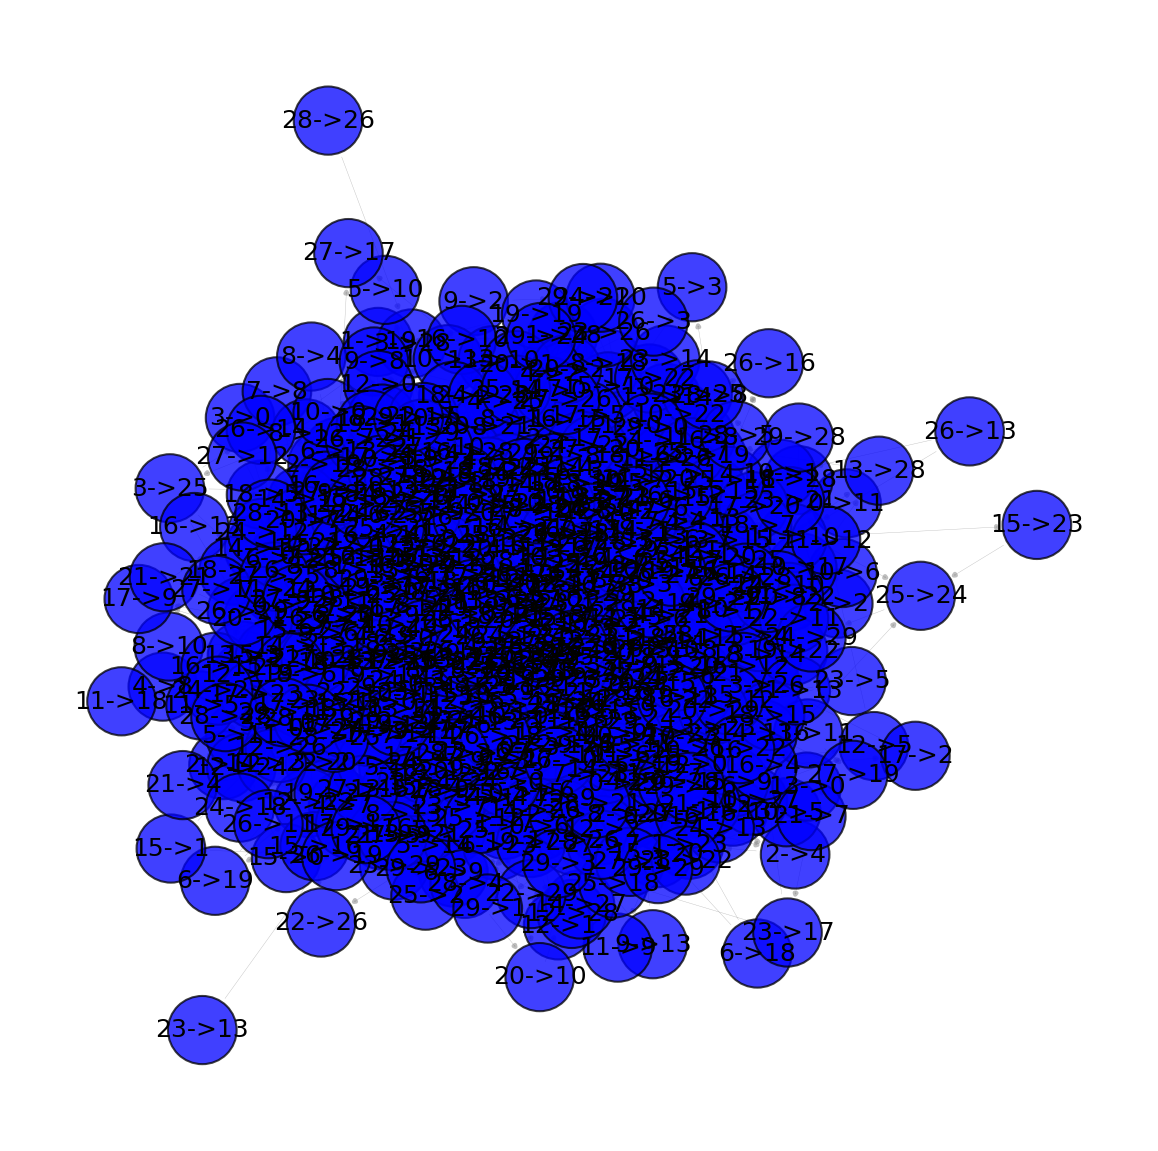

<pathpyG.visualisations._matplotlib.backend.MatplotlibBackend object at 0x74c577ce3250>

In [ ]:
_layout = pp.layout(g2_shuffled, layout='Fruchterman-Reingold', seed=1, iterations=300)
pp.plot(g2_shuffled, edge_size=0.1, edge_color='gray', node_color='blue', backend='matplotlib', layout=_layout)

We now find that the cluster pattern in the second-order graph has vanished. In fact, there is no pattern whatsoever since the underlying (static) graph topology is random and the random shuffling of time stamps leads to random causal paths.

## Spectral clustering with second-order graph Laplacian

To take a different perspective on cluster patterns, we can actually use `pathpyG` to apply a spectral analysis to the higher-order graph. We can simply calculate a generalization of the Laplacian matrix to the second-order graph both for the actual temporal graph and its shuffled counterpart:

In [ ]:
L = g2.laplacian(normalization='rw', edge_attr='edge_weight')
L_shuffled= g2_shuffled.laplacian(normalization='rw',edge_attr='edge_weight')

We then calculate the eigenvalues and eigenvectors of the Laplacians, and compute the Fiedler vector, i.e. the eigenvector that corresponds to the second-smallest eigenvalue of the Laplacian.

In [ ]:
w,v = sp.linalg.eig(L.todense(),left= False, right = True)
w_shuffled, v_shuffled = sp.linalg.eig(L_shuffled.todense())

In [ ]:
fiedler = v[:,np.argsort(w)[1]]
fiedler_shuffled = v_shuffled[:,np.argsort(w_shuffled)[1]]

Below, we show that the clusters in the causal topology of the temporal graph correspond to clusters in the distribution of entries in the Fiedler vector, while there is no such pattern for the Fiedler vector of the second-order graph constructed from the shuffled temporal graph:

In [ ]:
c = []
a = []
for v_1 in g2.nodes:
    if int(v_1[0]) < 10 and int(v_1[1]) < 10:
        c.append('green')
        a.append(1)
    elif int(v_1[0]) < 20 and int(v_1[0]) >= 10 and (int(v_1[1]) < 20) and (int(v_1[1]) >= 10):
        c.append('red')
        a.append(1)
    elif int(v_1[0]) < 30 and int(v_1[0]) >= 20 and (int(v_1[1]) < 30) and (int(v_1[1]) >= 20):
        c.append('blue')
        a.append(1)
    else:
        c.append('black')
        a.append(0.1)

In [ ]:
c_shuffled = []
a_shuffled = []
for v_2 in g2_shuffled.nodes:
    if int(v_2[0]) < 10 and int(v_2[1]) < 10:
        c_shuffled.append('green')
        a_shuffled.append(1)
    elif int(v_2[0]) < 20 and int(v_2[0]) >= 10 and (int(v_2[1]) < 20) and (int(v_2[1]) >= 10):
        c_shuffled.append('red')
        a_shuffled.append(1)
    elif int(v_2[0]) < 30 and int(v_2[0]) >= 20 and (int(v_2[1]) < 30) and (int(v_2[1]) >= 20):
        c_shuffled.append('blue')
        a_shuffled.append(1)
    else:
        c_shuffled.append('black')
        a_shuffled.append(0.1)

In the plots below, we have colored those entries of the Fiedler vectors that correspond to edges connecting nodes within one of the three clusters shown above. The Fiedler vector shows a clear pattern, which translates to the cluster pattern in the causal topology that we have planted into our synthetic temporal graph.

In [ ]:
plt.ylim(-.2, .25)
plt.scatter(range(g2.n), np.real(fiedler),c=c, alpha=a);

No such pattern exists in the Fiedler vector of the second-order graph corresponding to the shuffled `TemporalGraph`.

In [ ]:
plt.ylim(-.1, .1)
plt.scatter(range(g2_shuffled.n), np.real(fiedler_shuffled), c=c_shuffled, alpha=a_shuffled);

## Node Classification with Causality-Aware Graph Neural Networks

Let us now explore how we can develop a causality-aware deep graph learning architecture that utilizes this pattern in the causal topology. We will follow the architecture introduced [in this work](https://proceedings.mlr.press/v198/qarkaxhija22a.html). The architecture actually performs message passing in higher-order models with multiple orders at once. In a final message passing step, a bipartite graph is used to obtain vector-space representations of actual nodes in the temporal graph.

We now set up a `pytorch_geometric.Data` object that contains all of the information needed to train the DBGNN model. For this, we can use a convenience function of the `MultiOrderModel` class in `pathpyG`. Combining a first- and a second-order model, this uses the edge indices and the weight tensors for a message passing scheme. it further constructs an `edge_index` of a bipartite graph that uses the last node in a second-order node to map messages back to first-order nodes.

In [ ]:
data = m.to_dbgnn_data(max_order=2, mapping='last').to(device)
data.y = torch.tensor([ int(i) // 10 for i in t.mapping.node_ids], device=device)

## Training the model

We are now ready to train and evaluate our causality-aware graph neural network. We will frist create a random split of the nodes, set the optimizer and the hyperparameters of our model.

In [ ]:
data_1 = RandomNodeSplit(num_val=0, num_test=0.3)(data)
model = DBGNN(num_features=[g.n, g2.n], num_classes=len(data_1.y.unique()), hidden_dims=[16, 32, 8], p_dropout=0.4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_function = torch.nn.CrossEntropyLoss()

The following function evaluates the prediction of our model based on the balanced accuracy score for categorical predictions.

In [ ]:
def test(model, data):
    """Return the balanced accuracy of the model on the training and test set."""
    model.eval()

    _, pred = model(data).max(dim=1)

    metrics_train = balanced_accuracy_score(
        data.y[data.train_mask].cpu(),
        pred[data.train_mask].cpu().numpy()
        )

    metrics_test = balanced_accuracy_score(
        data.y[data.test_mask].cpu(),
        pred[data.test_mask].cpu().numpy()
        )

    return metrics_train, metrics_test

/media/vineetb/delta/projects/pathpyG/.venv/lib/python3.13/site-packages/coverage/control.py:958: CoverageWarning: No data was collected. (no-data-collected); see https://coverage.readthedocs.io/en/7.13.4/messages.html#warning-no-data-collected
  self._warn("No data was collected.", slug="no-data-collected")


E
ERROR: Coverage failure: total of 0 is less than fail-under=85
                                                                         [100%]
==================================== ERRORS ====================================
____________________________ ERROR at setup of test ____________________________
file /tmp/marimo_540985/__marimo__cell_rEll_.py, line 1
  def test(model, data):
E       fixture 'model' not found
>       available fixtures: anyio_backend, anyio_backend_name, anyio_backend_options, benchmark, benchmark_weave, capfd, capfdbinary, caplog, capsys, capsysbinary, capteesys, class_mocker, cov, doctest_namespace, free_tcp_port, free_tcp_port_factory, free_udp_port, free_udp_port_factory, mocker, module_mocker, monkeypatch, no_cover, package_mocker, pytestconfig, record_property, record_testsuite_property, record_xml_attribute, recwarn, session_mocker, subtests, tmp_path, tmp_path_factory, tmpdir, tmpdir_factory
>       use 'pytest --fixtures [testpath]' for help on them.


In [ ]:
losses = []
for epoch in range(100):
    output = model(data_1)
    loss = loss_function(output[data_1.train_mask], data_1.y[data_1.train_mask])
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    losses.append(loss)
    if epoch % 10 == 0:
        train_ba, test_ba = test(model, data_1)
        print(f'Epoch: {epoch}, Loss: {loss}, Train balanced accuracy: {train_ba}, Test balanced accuracy: {test_ba}')

Epoch: 0, Loss: 1.2924909591674805, Train balanced accuracy: 0.3333333333333333, Test balanced accuracy: 0.3333333333333333
Epoch: 10, Loss: 0.7062207460403442, Train balanced accuracy: 0.6666666666666666, Test balanced accuracy: 0.6666666666666666
Epoch: 20, Loss: 0.14961206912994385, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 30, Loss: 0.0028343815356492996, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 40, Loss: 0.0006139795877970755, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 50, Loss: 0.00016822836187202483, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 60, Loss: 7.88550460129045e-05, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 70, Loss: 5.531949136639014e-05, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 80, Loss: 4.647110472433269e-05, Train balanced accuracy: 1.0, Test balanced accuracy: 1.0
Epoch: 90, Loss: 4.19815223722253e-05, Train balanced accuracy: 1.0

# Causality-aware latent space representation of nodes

We can inspect the model by plotting a latent space representation of the edges generated by the second-order layer of our architecture.

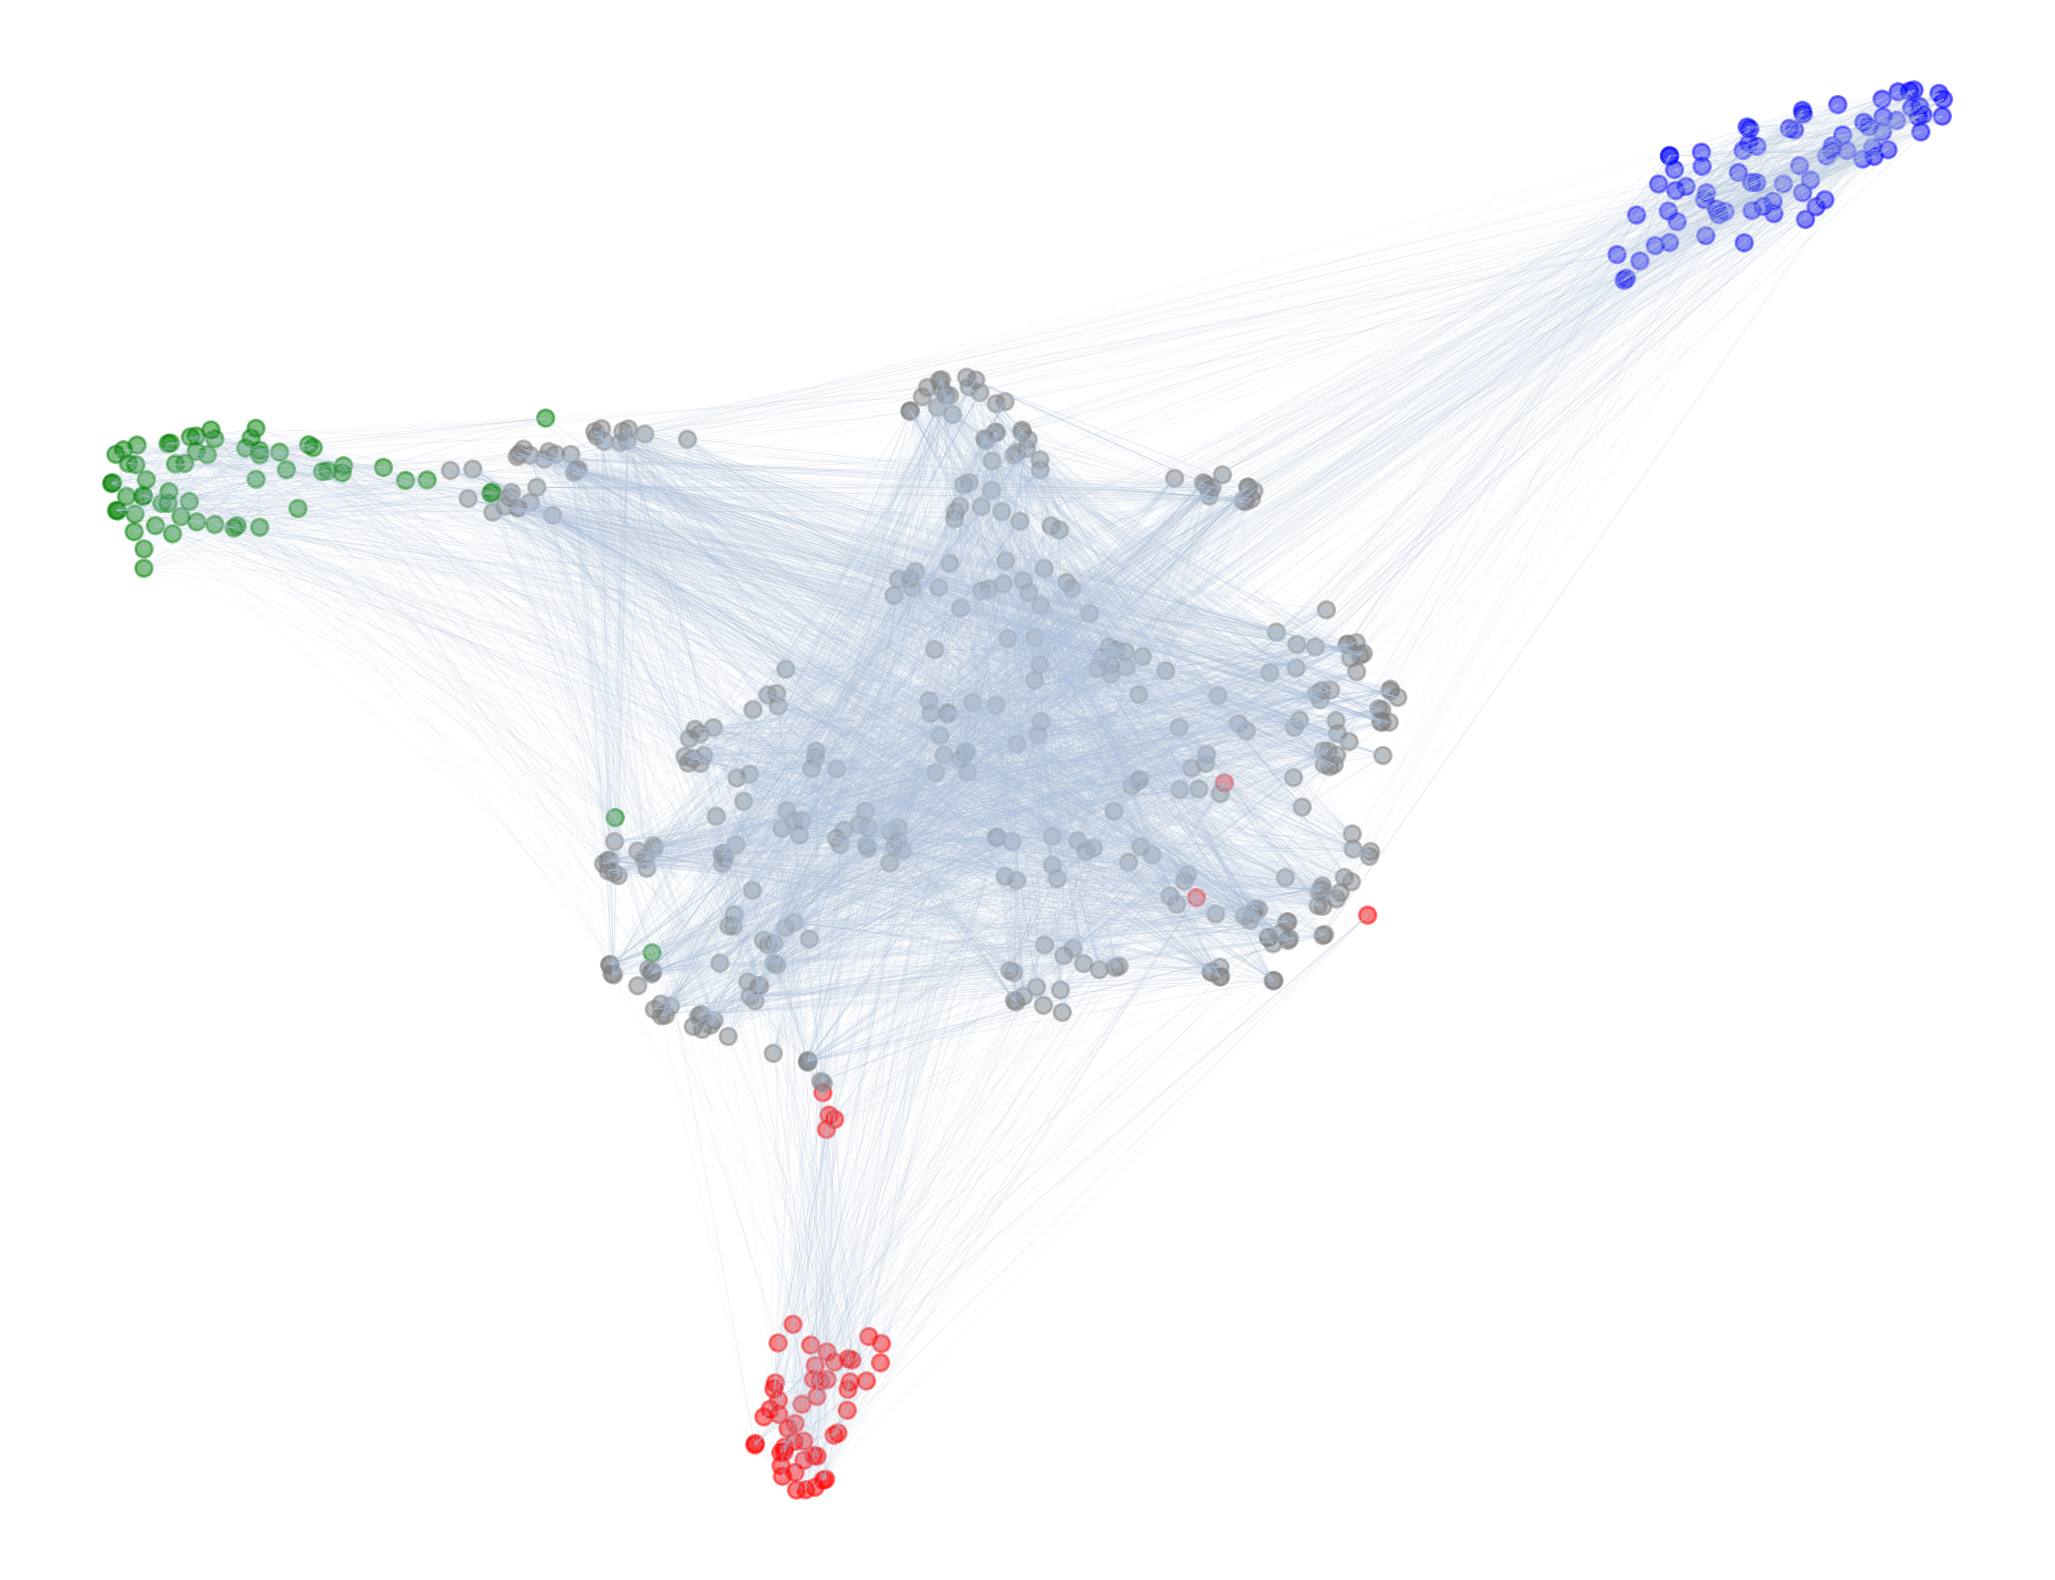

In [ ]:
model.eval()
_latent = model.higher_order_layers[0].forward(data_1.x_h, data_1.edge_index_higher_order).detach()
_latent = model.higher_order_layers[1].forward(_latent, data_1.edge_index_higher_order).detach()
_node_embedding = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(_latent.cpu())
_colors = []
for v_3, w_1 in g2.nodes:
    if data_1.y[g.mapping.to_idx(v_3)] == 0 and data_1.y[g.mapping.to_idx(w_1)] == 0:
        _colors.append('red')
    elif data_1.y[g.mapping.to_idx(v_3)] == 1 and data_1.y[g.mapping.to_idx(w_1)] == 1:
        _colors.append('green')
    elif data_1.y[g.mapping.to_idx(v_3)] == 2 and data_1.y[g.mapping.to_idx(w_1)] == 2:
        _colors.append('blue')
    else:
        _colors.append('grey')
plt.figure(figsize=(13, 10))
plt.scatter(_node_embedding[:, 0], _node_embedding[:, 1], c=_colors, alpha=0.5)
for _e in g2.edges:
    _src = g2.mapping.to_idx(_e[0])
    _tgt = g2.mapping.to_idx(_e[1])
    plt.plot([_node_embedding[_src, 0], _node_embedding[_tgt, 0]], [_node_embedding[_src, 1], _node_embedding[_tgt, 1]], color='lightsteelblue', linestyle='-', alpha=0.2, lw=0.2)
plt.axis('off')
plt.show()

We can further generate latent space representations of the nodes generated by the last bipartite layer of our architecture:

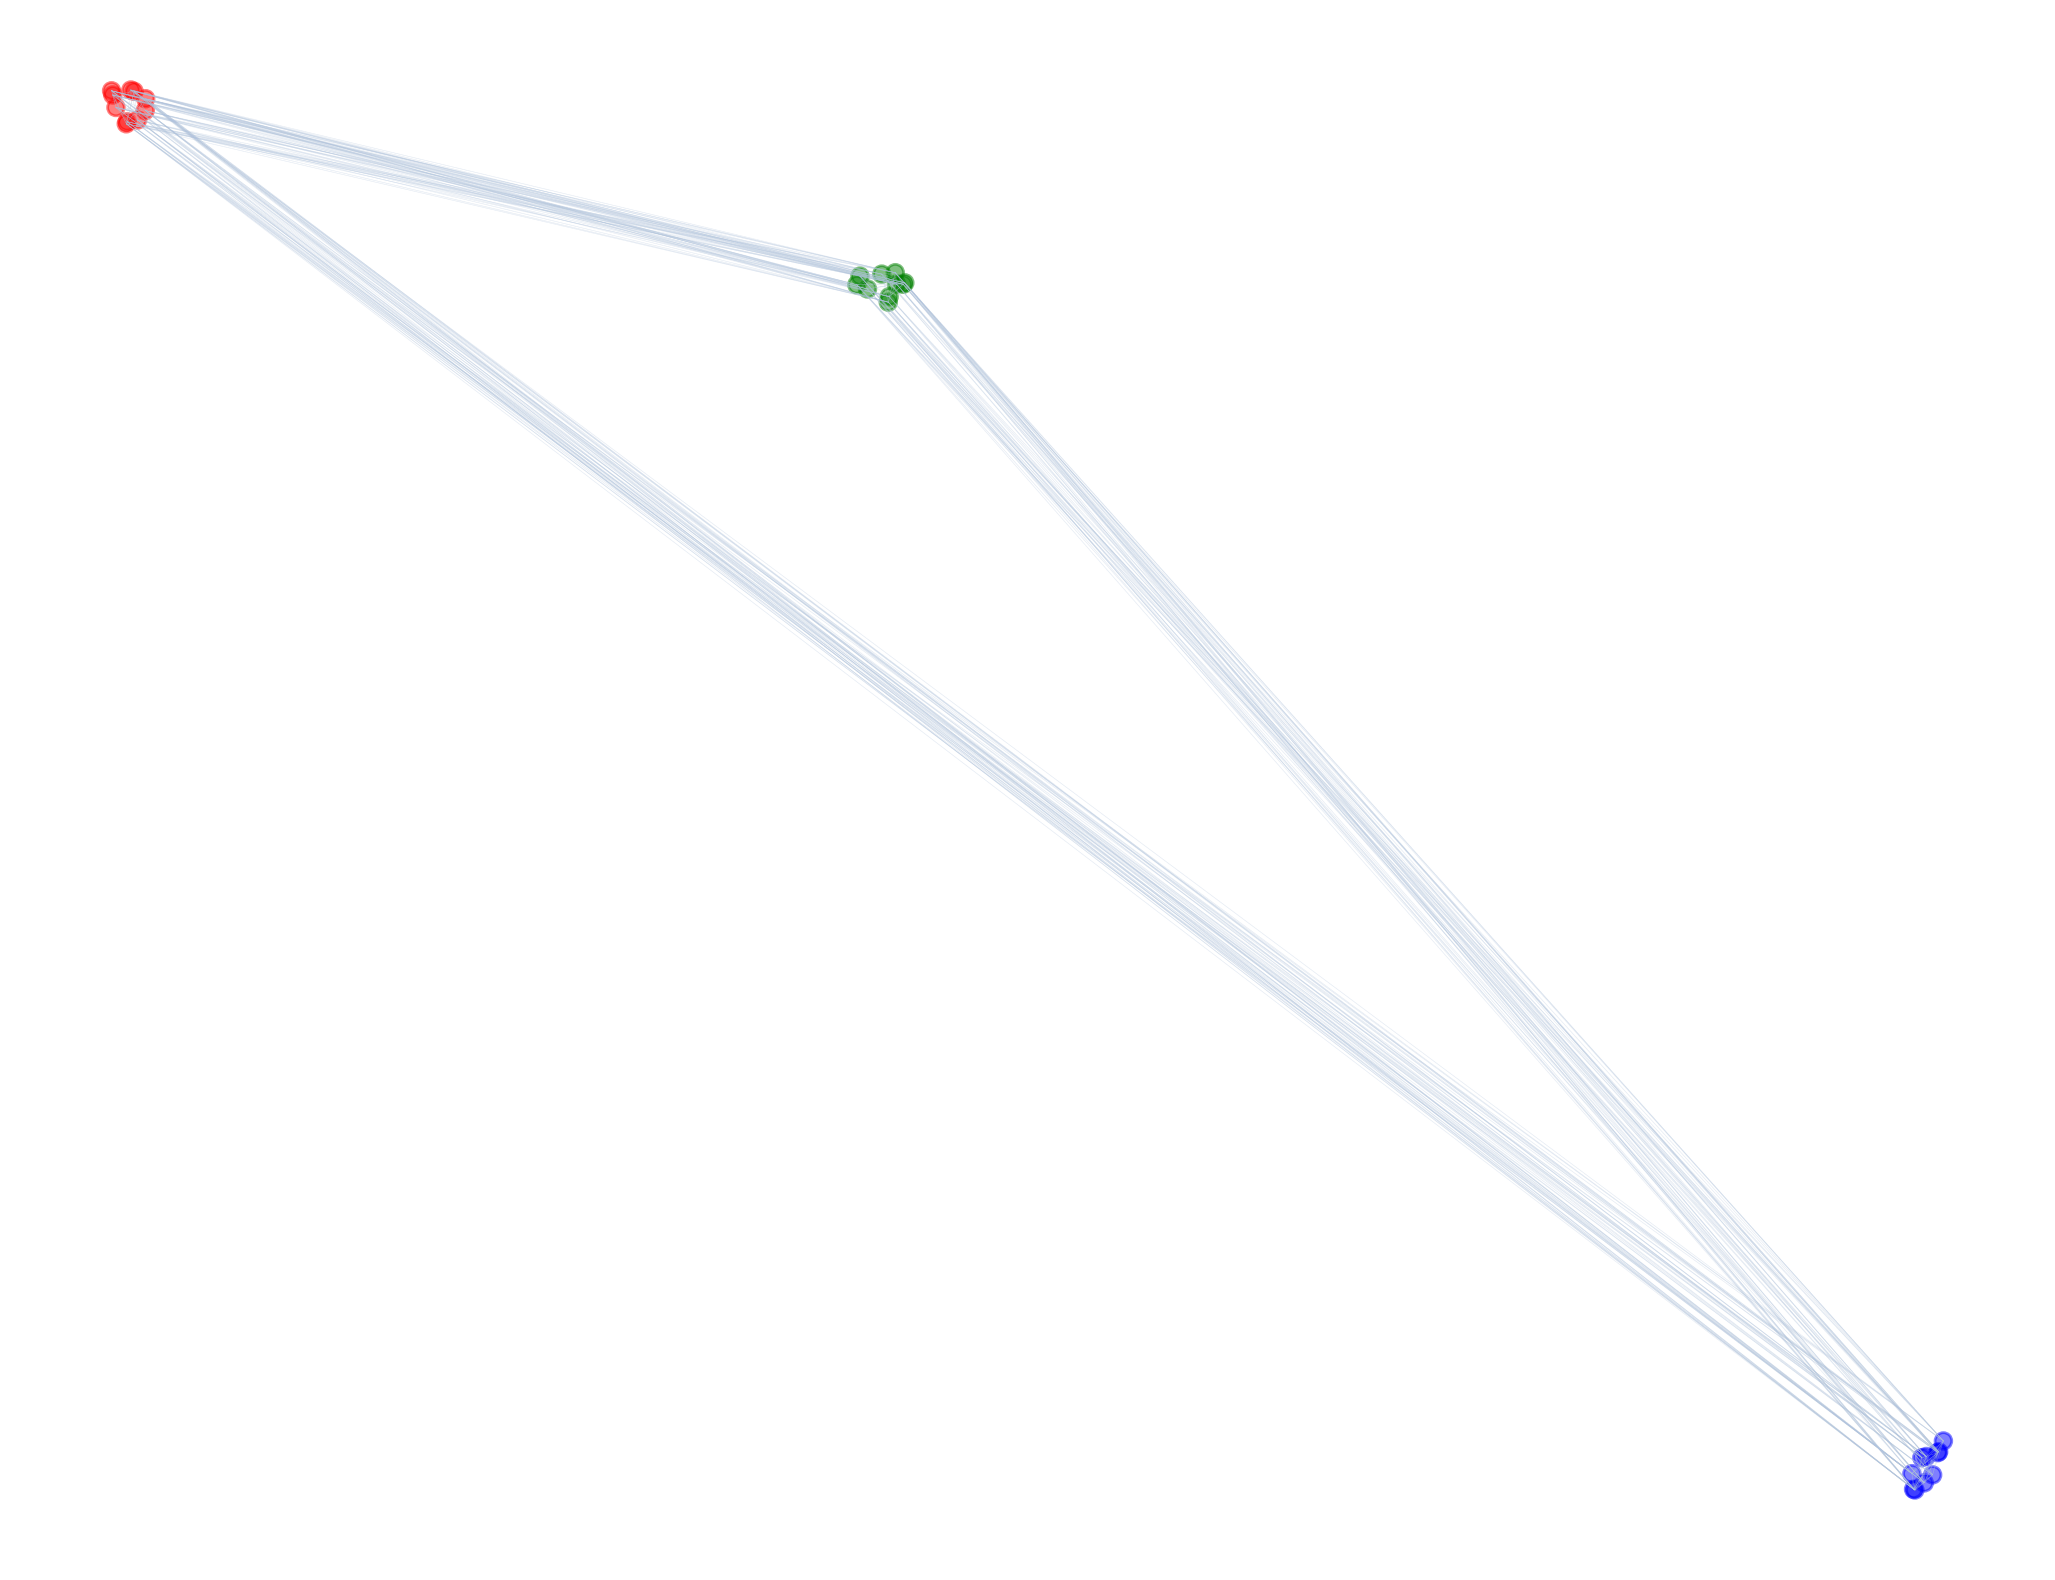

In [ ]:
model.eval()
_latent = model.forward(data_1).detach()
_node_embedding = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=10).fit_transform(_latent.cpu())
_colors = []
for v_4 in g.nodes:
    if data_1.y[g.mapping.to_idx(v_4)] == 0:
        _colors.append('red')
    elif data_1.y[g.mapping.to_idx(v_4)] == 1:
        _colors.append('green')
    elif data_1.y[g.mapping.to_idx(v_4)] == 2:
        _colors.append('blue')
    else:
        _colors.append('grey')
plt.figure(figsize=(13, 10))
plt.scatter(_node_embedding[:, 0], _node_embedding[:, 1], c=_colors, alpha=0.5)
for _e in g.edges:
    _src = g.mapping.to_idx(_e[0])
    _tgt = g.mapping.to_idx(_e[1])
    plt.plot([_node_embedding[_src, 0], _node_embedding[_tgt, 0]], [_node_embedding[_src, 1], _node_embedding[_tgt, 1]], color='lightsteelblue', linestyle='-', alpha=0.2, lw=0.2)
plt.axis('off')
plt.show()